In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

2025-05-18 16:29:04.007319: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-18 16:29:04.008482: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-18 16:29:04.015919: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-18 16:29:04.038015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747565944.072777    7727 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747565944.08

In [2]:
base_dir = "./Dataset"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

In [3]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42  # For reproducible shuffling/splitting

# ======================
# 3. Load Raw Datasets
initial_load = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED
)
class_names = initial_load.class_names
print("Class names:", class_names)

# 4. Proper dataset loading with all transformations
def create_dataset(subset=None, shuffle=True):
    return image_dataset_from_directory(
        train_dir if subset else test_dir,
        validation_split=0.2 if subset else None,
        subset=subset,
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        shuffle=shuffle
    ).map(lambda x, y: (x/255.0, y))  # Normalize here

train_dataset = create_dataset("training")
val_dataset = create_dataset("validation")
test_dataset = create_dataset(shuffle=False)  # No subset for test data



Found 34277 files belonging to 5 classes.
Using 27422 files for training.


2025-05-18 16:29:13.182138: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Class names: ['Bio-degradable', 'Electronic', 'Medical', 'Non-degradable', 'Recyclable']
Found 34277 files belonging to 5 classes.
Using 27422 files for training.
Found 34277 files belonging to 5 classes.
Using 6855 files for validation.
Found 8673 files belonging to 5 classes.


In [4]:
# 5. Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [5]:
# 6. Verification
def check_normalization(dataset, name):
    for images, _ in dataset.take(1):
        print(f"{name} - Min: {images.numpy().min():.2f}, Max: {images.numpy().max():.2f}")

check_normalization(train_dataset, "Training set")
check_normalization(val_dataset, "Validation set")
check_normalization(test_dataset, "Test set")


2025-05-18 16:29:19.506332: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-05-18 16:29:19.527009: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-05-18 16:29:19.613458: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

Training set - Min: 0.00, Max: 1.00
Validation set - Min: 0.00, Max: 1.00
Test set - Min: 0.00, Max: 1.00


2025-05-18 16:29:19.834410: W tensorflow/core/kernels/data/cache_dataset_ops.cc:916] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-05-18 16:29:20.072640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


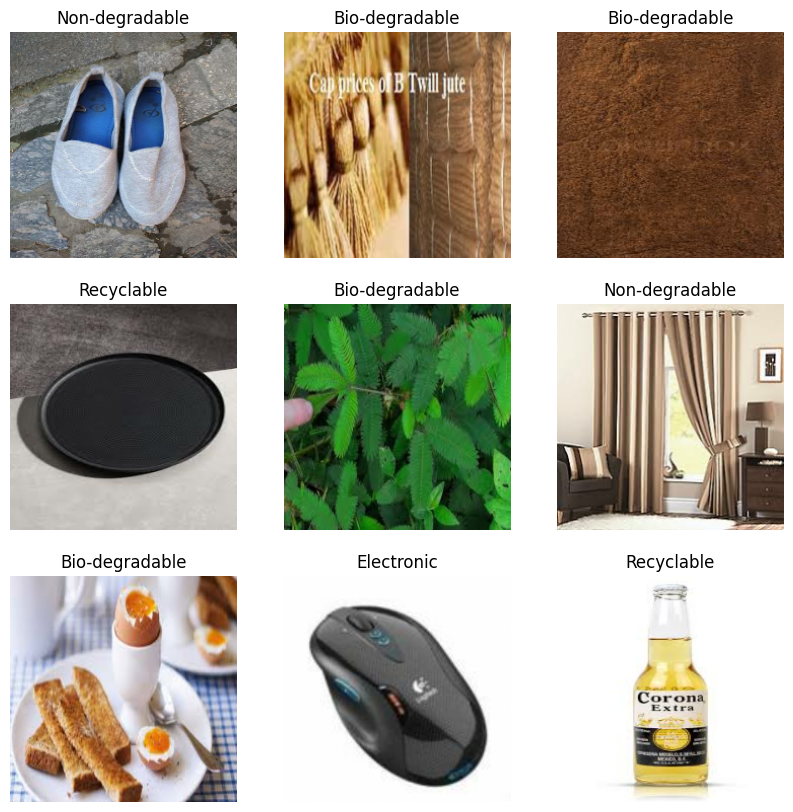

In [6]:
# 7. Visualization
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.show()

In [7]:
#Function to count images per class
def get_class_distribution(directory):
    counts = {}
    for class_name in os.listdir(directory):
        class_dir = os.path.join(directory, class_name)
        if os.path.isdir(class_dir):  # Ensure it's a directory
            counts[class_name] = len(os.listdir(class_dir))
    return counts

#Get distributions
train_counts = get_class_distribution(train_dir)
test_counts = get_class_distribution(test_dir)


Class Distribution:
                Train  Test  Total
Medical          1856   499   2355
Bio-degradable  11732  2812  14544
Non-degradable   7582  2188   9770
Recyclable      10091  2546  12637
Electronic       3016   628   3644


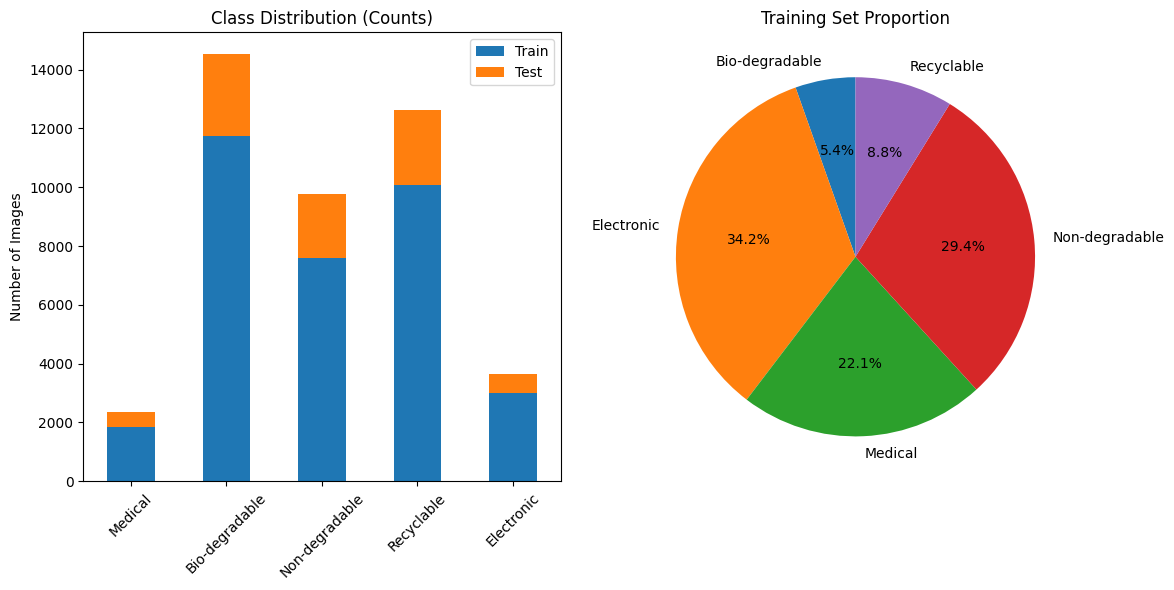


Class Imbalance Ratios (Max/Min):
Medical: 6.3x (times)
Bio-degradable: 1.0x (times)
Non-degradable: 1.5x (times)
Recyclable: 1.2x (times)
Electronic: 3.9x (times)


In [8]:
# Create DataFrames for visualization
train_df = pd.DataFrame.from_dict(train_counts, orient='index', columns=['Train'])
test_df = pd.DataFrame.from_dict(test_counts, orient='index', columns=['Test'])
dist_df = pd.concat([train_df, test_df], axis=1)
dist_df['Total'] = dist_df['Train'] + dist_df['Test']

print("\nClass Distribution:")
print(dist_df)

# Visualization
plt.figure(figsize=(12, 6))

# Bar plot
plt.subplot(1, 2, 1)
dist_df[['Train', 'Test']].plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Class Distribution (Counts)')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)

# Pie chart (percentage)
plt.subplot(1, 2, 2)
dist_df['Train'].plot(kind='pie', autopct='%1.1f%%', 
                     labels=class_names, startangle=90)
plt.title('Training Set Proportion')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 5. Calculate imbalance ratios
max_count = dist_df['Train'].max()
imbalance_ratios = {cls: max_count/count for cls, count in train_counts.items()}

print("\nClass Imbalance Ratios (Max/Min):")
for cls, ratio in imbalance_ratios.items():
    print(f"{cls}: {ratio:.1f}x (times)")

In [9]:
from tensorflow.keras import layers
import tensorflow as tf

# 1. First get the class indices as constants
MEDICAL_IDX = tf.constant(class_names.index("Medical"), dtype=tf.int64)
ELECTRONIC_IDX = tf.constant(class_names.index("Electronic"), dtype=tf.int64)

# 2. Augmentation layers
base_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
])

aggressive_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5),
    layers.RandomZoom(0.3),
    layers.RandomBrightness(0.3),
    layers.RandomContrast(0.3),
])

# 3. Fixed augmentation function
def augment_data(image, label):
    class_idx = tf.argmax(label)
    
    # Use tf.cond for TensorFlow-compatible conditional logic
    image = tf.cond(
        tf.equal(class_idx, MEDICAL_IDX),
        lambda: aggressive_augmentation(image),
        lambda: tf.cond(
            tf.equal(class_idx, ELECTRONIC_IDX),
            lambda: aggressive_augmentation(image),
            lambda: base_augmentation(image)
        )
    )
    
    return image, label

# 4. Apply augmentation
augmented_train = train_dataset.map(
    augment_data,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Keep original validation/test sets
val_dataset = val_dataset
test_dataset = test_dataset

# Final optimized datasets
train_dataset = augmented_train.cache().prefetch(AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [12]:
# 7. Visualize Preprocessed and Augmented Images
def visualize_augmented_dataset(dataset, class_names, num_images=9):
    plt.figure(figsize=(10, 10))
    for images, labels in dataset.take(1):  # Take one batch
        images = images.numpy()
        labels = labels.numpy()
        for i in range(num_images):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i])
            label_index = np.argmax(labels[i])  # Convert one-hot to class index
            plt.title(class_names[label_index])
            plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_augmented_dataset(train_dataset, class_names)


InvalidArgumentError: {{function_node __wrapped__IteratorGetNext_output_types_2_device_/job:localhost/replica:0/task:0/device:CPU:0}} Error in user-defined function passed to ParallelMapDatasetV2:46 transformation with iterator: Iterator::Root::Prefetch::FiniteTake::Prefetch::MemoryCacheImpl::ParallelMapV2: The second input must be a scalar, but it has shape [5]
	 [[{{node cond/cond_input_4/_9}}]] [Op:IteratorGetNext] name: 

<Figure size 1000x1000 with 0 Axes>

In [ ]:
def check_class_distribution(dataset, class_names):
    class_counts = {name: 0 for name in class_names}
    
    try:
        for images, labels in dataset:
            # Safely convert one-hot to class indices
            class_indices = tf.argmax(labels, axis=1).numpy()
            for idx in class_indices:
                class_counts[class_names[idx]] += 1
                
    except Exception as e:
        print(f"Error during processing: {e}")
        print("Trying alternative approach...")
        
        # Fallback method
        from collections import defaultdict
        class_counts = defaultdict(int)
        for images, labels in dataset.unbatch().take(1000):  # Check first 1000 samples
            class_idx = tf.argmax(labels).numpy()
            class_counts[class_names[class_idx]] += 1
    
    # Visualization
    plt.figure(figsize=(10, 5))
    bars = plt.bar(class_counts.keys(), class_counts.values())
    plt.title("Class Distribution After Augmentation")
    plt.xlabel("Classes")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    
    # Add count labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height}',
                ha='center', va='bottom')
    
    plt.show()
    
    return class_counts

# Usage
augmented_class_dist = check_class_distribution(train_dataset, class_names)
print("Class counts:", augmented_class_dist)